In [2]:
# 1. Birthday Collisions [20 points]

# Returns float: the probability of the collision of 2 people
#                sharing a birthday.
def p_shared(n):
   DAYSINYEAR = 365
   # Use complement rule to find if 2 people share two birthdays.
   # It is easier than finding pair, but finding where nobody 
   # shares is easier. We use permutations.
   # 1 - where everyone has a different birthday.

   permutation = 1  # set to 1 so it does not zero.
   # Numerator: uses permutation because we have different 
   #            birthdays where order matters, with no repeats.
   # Denominator: we use product rule for denominator because 
   #              365^n counts tuples each n has 365 choices.
   for i in range(0, n):
      permutation = permutation * (DAYSINYEAR - i)
   return 1 - permutation / (365** n)

for i in range(5, 50 + 1, 5):
   print(f"p_shared({i}): ", p_shared(i))

p_shared(5):  0.02713557369979358
p_shared(10):  0.11694817771107768
p_shared(15):  0.25290131976368635
p_shared(20):  0.41143838358057994
p_shared(25):  0.5686997039694639
p_shared(30):  0.7063162427192686
p_shared(35):  0.8143832388747152
p_shared(40):  0.891231809817949
p_shared(45):  0.940975899465775
p_shared(50):  0.9703735795779884


In [61]:
# 1b.) Print the smallest n with a probability greater than 0.50.
#      Print the smallest n with a probability greater than 0.99.
n = 1
COLLISION_PROB_HALF = 0.5
COLLISION_PROB_NINETY_NINE = 0.99
# We search going up from n = 1 until we find the n 
# that passes the collision probability (0.5 and 0.99)
while p_shared(n) <= COLLISION_PROB_HALF:
   n += 1
   # print(f"p_shared({n}): {p_shared(n):.4f}") # test
lowest_n_half = n

n = 1
while p_shared(n) <= COLLISION_PROB_NINETY_NINE:
   n += 1
   # print(f"p_shared({n}): {p_shared(n):.4f}") # test
lowest_n_ninety_nine = n

print("Lowest n for 0.5:", lowest_n_half)
print(f"Value: {p_shared(lowest_n_half):.4f}")
print("Lowest n for 0.99:", lowest_n_ninety_nine)
print(f"Value: {p_shared(lowest_n_ninety_nine):.4f}")

Lowest n for 0.5: 23
Value: 0.5073
Lowest n for 0.99: 57
Value: 0.9901


### Threshold Probability
How many people would it take to share a birthday, 
if the probability of collision to be 0.5?

Intuitively from our lecture slides it would about people.

We find that it is at least 23 people to share a birthday.

How many people would it take to share a birthday,
if the probability of collision was 0.99 ?

We find that it is at least 57 people to share a birthday.
We learned from the pigeonhole principle that it takes 
366 to be 100% certain. So collisions can happen earlier.


Bounds for 23 people , 0.6932
Bounds and Probability for 60


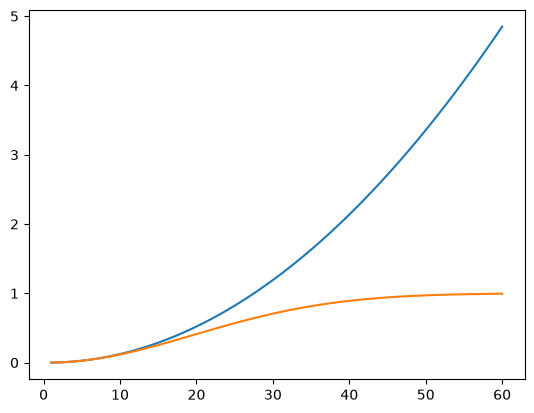

In [ ]:
# 1c.) Plot the exact probability and the bound against:
#      p_shared(n) <= (n, 2) / 365. Bound: 1, ... , 60.
#      Then plot, y - axis: exact probability, 
#                 x - axis: one for n (bounds)

import matplotlib.pyplot as plt # W3 Schools
# print(plt.__version__) # confirm installation.

x_values = []        # the n or number of people 
y_values_exact = []  # the exact probability
y_values_bounds = [] # the probability of bounds
def union_bound(n):
   DAYS_IN_YEAR = 365
   orders_per_pair = 2 # (Jane, John), (John, Jane)
   # The total ordered pairs that are double counted (A, B), (B, A)
   ordered_pairs = (n * (n - 1))
   # We find the true number of pairs without the double count
   number_of_pairs = (ordered_pairs / orders_per_pair) 
   # Each pair has a probability 1 / 365 giving us the total.
   union_bound_probability = number_of_pairs / DAYS_IN_YEAR
   return union_bound_probability

# n = 23
# print(f"Bounds for {n} people , {union_bound(n):.4f}") # test

bounds = 60
print(f"Bounds and Probability for {bounds}")
for i in range (1, bounds + 1):
   result = union_bound(i)
   x_values.append(i)   
   y_values_bounds.append(result)
   y_values_exact.append(p_shared(i))

   # print(f"Bound:    {i}: {result:.4f}") # test
   # print(f"p_shared: {i}: {p_shared(i):.4f}") # test

# plt.plot(xpoints, ypoints) (W3 schools)
plt.xlabel("Number of people: ")
plt.ylabel("")
plt.plot(x_values, y_values_bounds)
plt.plot(x_values, y_values_exact)
plt.show()